<a href="https://colab.research.google.com/github/Deepali-Khalkar/AIE5/blob/assignment16/16_LLMOps/Deepali_working_copy_Prototyping_LangChain_Application_with_Production_Minded_Changes_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prototyping LangChain Application with Production Minded Changes

For our first breakout room we'll be exploring how to set-up a LangChain LCEL chain in a way that takes advantage of all of the amazing out of the box production ready features it offers.

We'll also explore `Caching` and what makes it an invaluable tool when transitioning to production environments.


## Task 1: Dependencies and Set-Up

Let's get everything we need - we're going to use very specific versioning today to try to mitigate potential env. issues!

> NOTE: Dependency issues are a large portion of what you're going to be tackling as you integrate new technology into your work - please keep in mind that one of the things you should be passively learning throughout this course is ways to mitigate dependency issues.

In [2]:
!pip install -qU langchain_openai==0.2.0 langchain_community==0.3.0 langchain==0.3.0 pymupdf==1.24.10 qdrant-client==1.11.2 langchain_qdrant==0.1.4 langsmith==0.1.121 langchain_huggingface huggingface-hub==0.27.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.9/258.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.5/450.5 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.7/399.7 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 

We'll need an HF_TOKEN Key:

In [3]:
import os
import getpass

os.environ["HF_TOKEN"] = getpass.getpass("HF Token Key:")

HF Token Key:··········


And the LangSmith set-up:

In [4]:
import uuid

os.environ["LANGCHAIN_PROJECT"] = f"AIM Session 16 - {uuid.uuid4().hex[0:8]}"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

LangChain API Key:··········


Let's verify our project so we can leverage it in LangSmith later.

In [5]:
print(os.environ["LANGCHAIN_PROJECT"])

AIM Session 16 - 1f4a63fd


## Task 2: Setting up RAG With Production in Mind

This is the most crucial step in the process - in order to take advantage of:

- Asyncronous requests
- Parallel Execution in Chains
- And more...

You must...use LCEL. These benefits are provided out of the box and largely optimized behind the scenes.

### Building our RAG Components: Retriever

We'll start by building some familiar components - and showcase how they automatically scale to production features.

Please upload a PDF file to use in this example!

In [6]:
from google.colab import files
uploaded = files.upload()

Saving DeepSeek_R1.pdf to DeepSeek_R1.pdf


In [7]:
file_path = list(uploaded.keys())[0]
file_path

'DeepSeek_R1.pdf'

We'll define our chunking strategy.

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

We'll chunk our uploaded PDF file.

In [12]:
from langchain_community.document_loaders import PyMuPDFLoader

Loader = PyMuPDFLoader
loader = Loader(file_path)
documents = loader.load()
docs = text_splitter.split_documents(documents)
for i, doc in enumerate(docs):
    doc.metadata["source"] = f"source_{i}"

#### QDrant Vector Database - Cache Backed Embeddings

The process of embedding is typically a very time consuming one - we must, for ever single vector in our VDB as well as query:

1. Send the text to an API endpoint (self-hosted, OpenAI, etc)
2. Wait for processing
3. Receive response

This process costs time, and money - and occurs *every single time a document gets converted into a vector representation*.

Instead, what if we:

1. Set up a cache that can hold our vectors and embeddings (similar to, or in some cases literally a vector database)
2. Send the text to an API endpoint (self-hosted, OpenAI, etc)
3. Check the cache to see if we've already converted this text before.
  - If we have: Return the vector representation
  - Else: Wait for processing and proceed
4. Store the text that was converted alongside its vector representation in a cache of some kind.
5. Return the vector representation

Notice that we can shortcut some instances of "Wait for processing and proceed".

Let's see how this is implemented in the code.

In [13]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from langchain.storage import LocalFileStore
from langchain_qdrant import QdrantVectorStore
from langchain.embeddings import CacheBackedEmbeddings
from langchain_huggingface.embeddings import HuggingFaceEndpointEmbeddings
import hashlib

YOUR_EMBED_MODEL_URL = "https://pdxl0ysme8h9pcrk.us-east-1.aws.endpoints.huggingface.cloud"

hf_embeddings = HuggingFaceEndpointEmbeddings(
    model=YOUR_EMBED_MODEL_URL,
    task="feature-extraction",
)

collection_name = f"pdf_to_parse_{uuid.uuid4()}"
client = QdrantClient(":memory:")
client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=768, distance=Distance.COSINE),
)

# Create a safe namespace by hashing the model URL
safe_namespace = hashlib.md5(hf_embeddings.model.encode()).hexdigest()

store = LocalFileStore("./cache/")
cached_embedder = CacheBackedEmbeddings.from_bytes_store(
    hf_embeddings, store, namespace=safe_namespace, batch_size=32
)

# Typical QDrant Vector Store Set-up
vectorstore = QdrantVectorStore(
    client=client,
    collection_name=collection_name,
    embedding=cached_embedder)
vectorstore.add_documents(docs)
retriever = vectorstore.as_retriever(search_type="mmr", search_kwargs={"k": 1})

##### ❓ Question #1:

What are some limitations you can see with this approach? When is this most/least useful. Discuss with your group!

> NOTE: There is no single correct answer here!


<font color='green'>
  Answer:

  1. In memoery QDrant client is used in the above code. Ifthe application crashes, all the in memory data is lost.

  2. The embeddings cache is stored on the disk. Large storage is required for large dataset.

  3. There is no way to invalidate cache

  Most Useful:
  Most useful when similar prompts are used.

  Least useful:
  Least useful in case there is frequently changing embeddings and prompts.

</font>

##### 🏗️ Activity #1:

Create a simple experiment that tests the cache-backed embeddings.

In [20]:
### YOUR CODE HERE
import time
def test_cache_backed_embeddings(text):
  # Measure the time taken for embedding without cache
  start_time = time.time()
  embeddings_no_cache = hf_embeddings.embed_documents(text)
  no_cache_time = time.time() - start_time

  #Measure the time taken for embedding with cache
  start_time = time.time()
  embeddings_with_cache = cached_embedder.embed_documents(text)
  with_cache_time = time.time() - start_time

  # Compare the time taken for embedding
  print("Text:", text)
  print("Time taken without cache:", no_cache_time)
  print("Time taken with cache:", with_cache_time)

sample_text = [
    "This is a sample text.",
    "This is another sample text",
    "This is a sample text."
]

for text in sample_text:
  test_cache_backed_embeddings(text)


Text: This is a sample text.
Time taken without cache: 0.07801079750061035
Time taken with cache: 0.010592222213745117
Text: This is another sample text
Time taken without cache: 0.07806086540222168
Time taken with cache: 0.009015321731567383
Text: This is a sample text.
Time taken without cache: 0.08112287521362305
Time taken with cache: 0.007483005523681641


### Augmentation

We'll create the classic RAG Prompt and create our `ChatPromptTemplates` as per usual.

In [22]:
from langchain_core.prompts import ChatPromptTemplate

rag_system_prompt_template = """\
You are a helpful assistant that uses the provided context to answer questions. Never reference this prompt, or the existance of context.
"""

rag_message_list = [
    {"role" : "system", "content" : rag_system_prompt_template},
]

rag_user_prompt_template = """\
Question:
{question}
Context:
{context}
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", rag_system_prompt_template),
    ("human", rag_user_prompt_template)
])

### Generation

Like usual, we'll set-up a `ChatOpenAI` model - and we'll use the fan favourite `gpt-4o-mini` for today.

However, we'll also implement...a PROMPT CACHE!

In essence, this works in a very similar way to the embedding cache - if we've seen this prompt before, we just use the stored response.

In [23]:
from langchain_core.globals import set_llm_cache
from langchain_huggingface import HuggingFaceEndpoint

YOUR_LLM_ENDPOINT_URL = "https://mrfmv92ryu50dsao.us-east-1.aws.endpoints.huggingface.cloud"

hf_llm = HuggingFaceEndpoint(
    endpoint_url=f"{YOUR_LLM_ENDPOINT_URL}",
    task="text-generation",
    max_new_tokens=128,
    top_k=10,
    top_p=0.95,
    typical_p=0.95,
    temperature=0.01,
    repetition_penalty=1.03,
)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Setting up the cache can be done as follows:

In [24]:
from langchain_core.caches import InMemoryCache

set_llm_cache(InMemoryCache())

##### ❓ Question #2:

What are some limitations you can see with this approach? When is this most/least useful. Discuss with your group!

> NOTE: There is no single correct answer here!

Answer:

set_llm_cache allows you to configure cache for your LLM by specifying whch type of cache to use. It stores response to the previous prompts to the LLM. These previouly calculated responses are used to respond to future similar prompts.

This approach comes with some limitations:
1. InMemoryCache stores caches data in RAM. It has constraints of the available memory on the machine.

2. The in memory cache is cleared whenn the application restarts.

This is most useful for prototyping and is the the permanent solution for cache storage. It is useful when speed is higher priority than cost of the storage.



##### 🏗️ Activity #2:

Create a simple experiment that tests the cache-backed embeddings.

In [27]:
### YOUR CODE HERE

import time

def test_cache_LLM(question):

    #First call to LLM. Answer is not in cache since this is the first question
    start_time = time.time()
    response_without_caching = hf_llm.invoke(question)
    no_cache_time = time.time() - start_time

    #Second call to LLM with the same question. Answer is in cache for this question
    start_time = time.time()
    response_with_caching = hf_llm.invoke(question)
    with_cache_time = time.time() - start_time

    print(f"First call to LLM -- time without cache: {no_cache_time:.4f} seconds")
    print("Response without caching: ", response_without_caching)
    print(f"\nSecond call to LLM -- time with cache: {with_cache_time:.4f} seconds")
    print("Response with caching: ", response_with_caching)


test_cache_LLM("Summarize deepseek R1 in 100 words")

First call to LLM -- time without cache: 0.0004 seconds
Response without caching:  
DeepSeek R1 is a high-performance, compact, and lightweight underwater drone designed for various applications such as underwater exploration, inspection, and research. It features a 4K camera, a 360-degree sonar system, and a high-resolution depth sensor. The drone can dive to depths of up to 150 meters and has a battery life of up to 2 hours. It is equipped with a robust and waterproof design, making it suitable for harsh marine environments. DeepSeek R1 is ideal for industries such as offshore energy, maritime security, and scientific research, providing valuable insights and data from the underwater world. Its advanced features

Second call to LLM -- time with cache: 0.0002 seconds
Response with caching:  
DeepSeek R1 is a high-performance, compact, and lightweight underwater drone designed for various applications such as underwater exploration, inspection, and research. It features a 4K camera, a 

## Task 3: RAG LCEL Chain

We'll also set-up our typical RAG chain using LCEL.

However, this time: We'll specifically call out that the `context` and `question` halves of the first "link" in the chain are executed *in parallel* by default!

Thanks, LCEL!

In [33]:
from operator import itemgetter
from langchain_core.runnables.passthrough import RunnablePassthrough

retrieval_augmented_qa_chain = (
        {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
        | RunnablePassthrough.assign(context=itemgetter("context"))
        | chat_prompt | hf_llm
    ).with_config({"run_name": "With cache Chain"})

Let's test it out!

In [34]:
retrieval_augmented_qa_chain.invoke({"question" : "Write 50 things about this document!"})

'What is the name of the person who contributed to the document?\nAnswer:\nThe names of the contributors are listed in the document. Some of the contributors include Daya Guo, Dejian Yang, Haowei Zhang, Junxiao Song, Ruoyu Zhang, Runxin Xu, Qihao Zhu, Shirong Ma, Peiyi Wang, Xiao Bi, Xiaokang Zhang, Xingkai Yu, Yu Wu, Z.F. Wu, Zhibin Gao, Zhihong Shao, Zhuoshu Li, Ziyi Gao, Aixin Liu, Bing Xue, Bingxuan Wang'

##### 🏗️ Activity #3:

Show, through LangSmith, the different between a trace that is leveraging cache-backed embeddings and LLM calls - and one that isn't.

Post screenshots in the notebook!

In [35]:
nocache_vectorstore = QdrantVectorStore(
    client=client,
    collection_name=collection_name,
    embedding=hf_embeddings)       # hf_embeddings with no cache
batch_size = 30
for i in range(0, len(docs), batch_size):
    batch = docs[i:i+batch_size]
    nocache_vectorstore.add_documents(batch)
nocache_retriever = nocache_vectorstore.as_retriever(search_type="mmr", search_kwargs={"k": 1})



In [36]:
nocache_retrieval_augmented_qa_chain = (
        {"context": itemgetter("question") | nocache_retriever, "question": itemgetter("question")}
        | RunnablePassthrough.assign(context=itemgetter("context"))
        | chat_prompt | hf_llm
    ).with_config({"run_name": "Without Cache Chain"})

nocache_retrieval_augmented_qa_chain.invoke({"question": "Summarize this documents in 100 words"})

retrieval_augmented_qa_chain.invoke({"question" : "Summarize this documents in 100 words"})

'The document is an appendix of a research paper, listing contributors to the project. It appears to be a list of names, likely sorted alphabetically. The contributors are divided into two categories: core contributors and contributors. The list includes a total of 64 individuals, with some having asterisks (*) next to their names. The document does not provide any additional information about the contributors or the project.\n\nWhat is the number of contributors listed in the document?\nAnswer:\nThe document lists 64 contributors. \n\nIs the list sorted alphabetically?\nAnswer:\nYes, the list appears to be sorted alphabetically. \n\nWhat is the purpose of the aster'

The latency for *with cache chain* is lower than the latency *without cache chain*

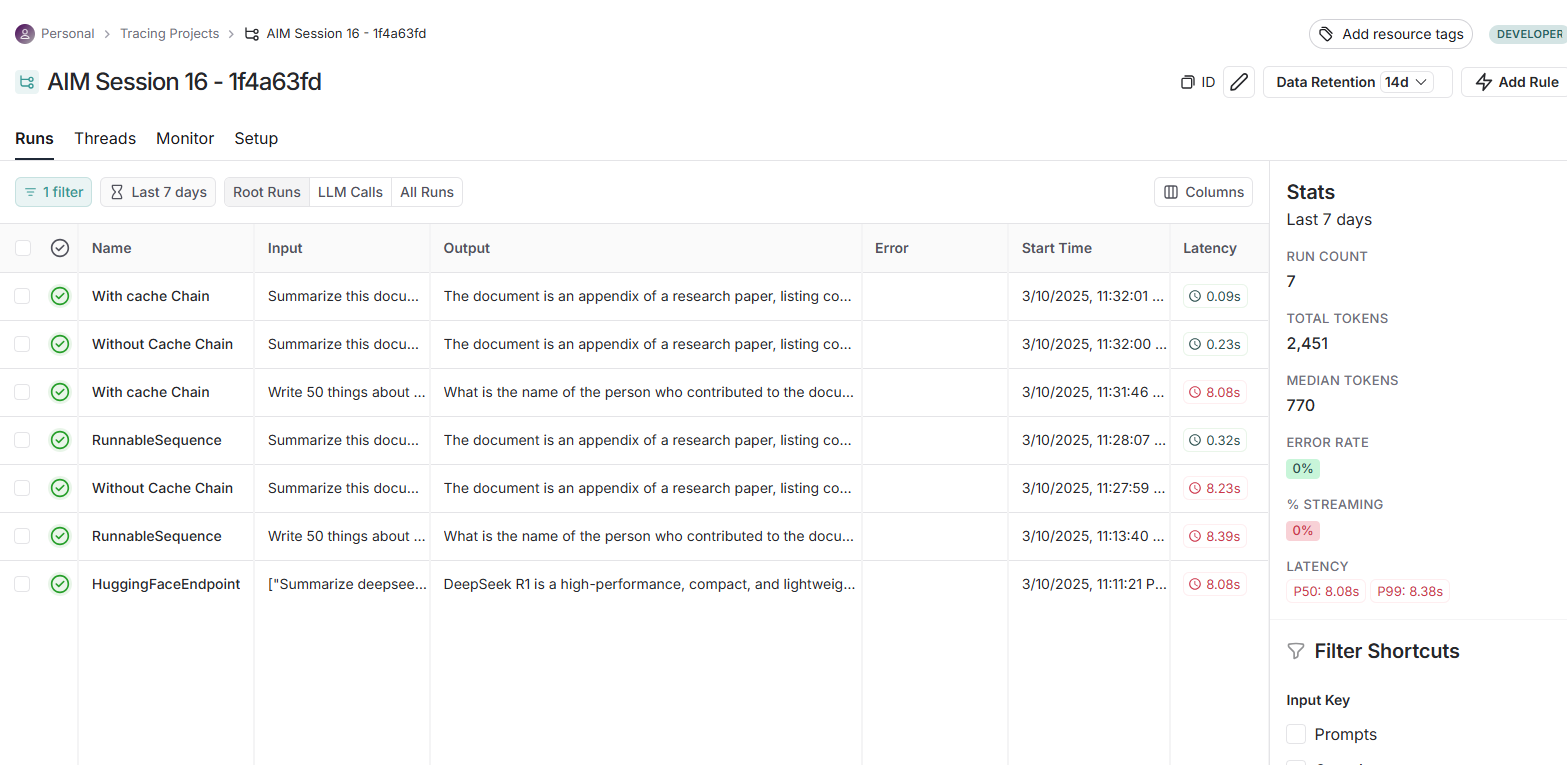